# Notes

Currently time series work even with duplicate measurement, but they are all on different graphs. Leaving that for now. Need to do soil profiles and check soil moisture and snow depth across sites.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

In [2]:
site = "TVC"
vari = "TSOI"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds_ctsm = df[f"{vari}"]
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")

C:\Users\madel\AppData\Local\Temp\ipykernel_35804\727719220.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [3]:
ds_ctsm

<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [4]:
ds_obs

<xarray.DataArray 'TSOI' (time: 350353, depth: 16)> Size: 45MB
[5605648 values with dtype=float64]
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 0.05 0.1 0.101 0.102 ... 0.9 1.04 1.16 1.17
Attributes:
    units:    °C

# Snow Depth Testing

In [5]:
site = "TVC" # testing with TVC cause it has snow depth dupes
vari = "SNOW_DEPTH"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
ds_ctsm = df[f"{vari}"]
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")
ds_obs = ds[f"{vari}"]
ds_obs = ds_obs.sortby("depth")


C:\Users\madel\AppData\Local\Temp\ipykernel_35804\3695594295.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [6]:
ds_obs

<xarray.DataArray 'SNOW_DEPTH' (time: 350353, depth: 2)> Size: 6MB
[700706 values with dtype=float64]
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 16B 0.0 1.0
Attributes:
    units:    cm

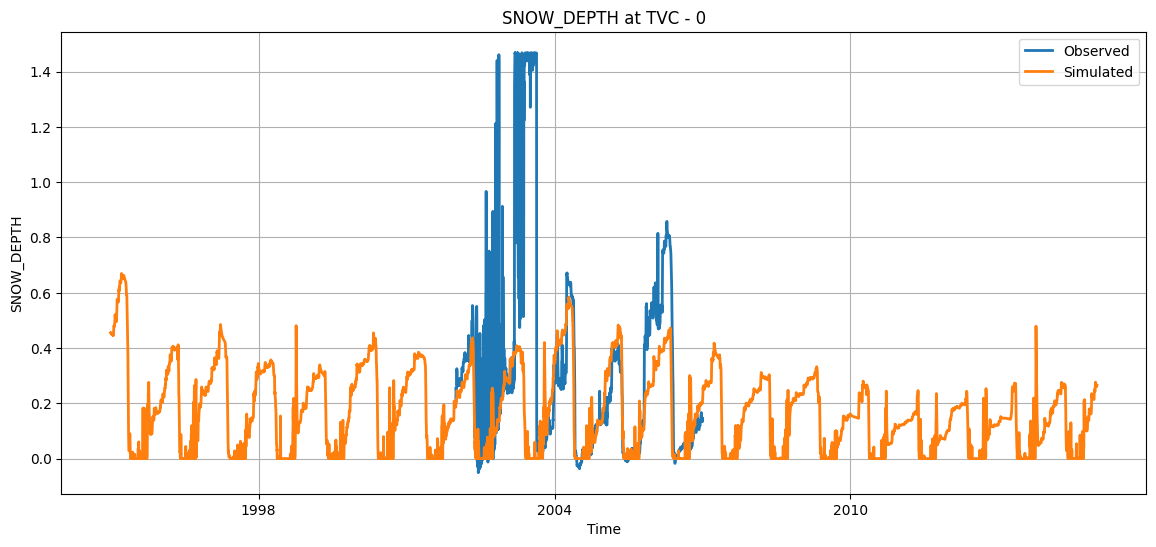

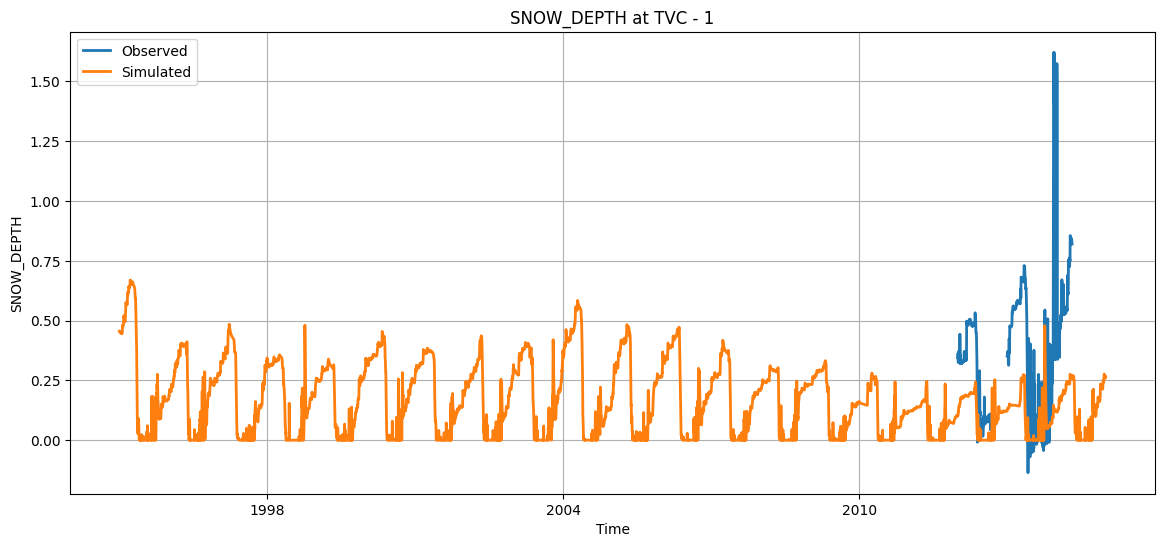

In [7]:
final_plot_sd(ds_obs, ds_ctsm, f"{site}", ds_obs.depth, f"{vari}", show=1)

In [8]:
era = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/ERA5/{vari}/processed/{site}/{site}_ERA5_SNOW_DEPTH.nc")

In [9]:
era["sde"]

<xarray.DataArray 'sde' (valid_time: 7305)> Size: 29kB
[7305 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 58kB 1995-01-01T12:00:00 ... 2014...
    expver      (valid_time) <U4 117kB ...
    latitude    float64 8B ...
    longitude   float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             3066
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      17091
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           sde
    GRIB_units:                               m
    long_name:                                Snow depth
    units:                                    m
    standard_name:                            lwe_thickness_of_surface_snow_a...
    GRIB_surface:                             0.0

In [114]:
def final_plot_sd(obs, sim, era5, site, depths, vari, show=0):

    if obs["time"].values.dtype == object:
        obs = obs.assign_coords(time=xr.CFTimeIndex(obs["time"].values).to_datetimeindex())
    obs_daily = obs.resample(time="1D").mean()

    sim = sim.squeeze()
    if sim["time"].values.dtype == object:
        sim = sim.assign_coords(time=xr.CFTimeIndex(sim["time"].values).to_datetimeindex())

    era5_time = era5["valid_time"].values

    plt.figure(figsize=(14,6))

    for i, x in enumerate(depths):
        plt.plot(
            obs_daily["time"].values,
            obs_daily.sel(depth=x.values, method="nearest").values/1000,
            label="Observed" if i == 0 else None,   # only label the first line
            color='steelblue',
            linewidth=2
        )

    plt.plot(sim["time"].values, sim.values, label="Simulated", color='darkorange', linewidth=2)
    plt.plot(era5_time, era5.values, label="ERA5-Land", color='forestgreen', linewidth=2)

    plt.xlabel("Time")
    plt.ylabel("Snow Depth (m)")
    plt.title("Snow Depth at TVC")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_combined.png", bbox_inches='tight')
    if not show:
        plt.close()

In [115]:
print("=== sim (ds_ctsm) ===")
print("type:", type(ds_ctsm))
print("time dtype:", ds_ctsm["time"].dtype)
print("time first value:", ds_ctsm["time"].values[0], "| python type:", type(ds_ctsm["time"].values[0]))
print("dims:", ds_ctsm.dims)
print("shape:", ds_ctsm.shape)
print()

print("=== era5 (era['sde']) ===")
print("type:", type(era["sde"]))
print("valid_time dtype:", era["sde"]["valid_time"].dtype)
print("valid_time first value:", era["sde"]["valid_time"].values[0], "| python type:", type(era["sde"]["valid_time"].values[0]))
print("dims:", era["sde"].dims)
print("shape:", era["sde"].shape)
print()

print("=== obs (ds_obs) ===")
print("type:", type(ds_obs))
print("time dtype:", ds_obs["time"].dtype)
print("time first value:", ds_obs["time"].values[0])
print("depth values:", ds_obs["depth"].values)
print("dims:", ds_obs.dims)

=== sim (ds_ctsm) ===
type: <class 'xarray.core.dataarray.DataArray'>
time dtype: object
time first value: 1995-01-01 00:00:00 | python type: <class 'cftime._cftime.DatetimeNoLeap'>
dims: ('time', 'lndgrid')
shape: (7300, 1)

=== era5 (era['sde']) ===
type: <class 'xarray.core.dataarray.DataArray'>
valid_time dtype: datetime64[ns]
valid_time first value: 1995-01-01T12:00:00.000000000 | python type: <class 'numpy.datetime64'>
dims: ('valid_time',)
shape: (7305,)

=== obs (ds_obs) ===
type: <class 'xarray.core.dataarray.DataArray'>
time dtype: object
time first value: 1995-01-01 00:00:00
depth values: [0. 1.]
dims: ('time', 'depth')


C:\Users\madel\AppData\Local\Temp\ipykernel_32088\1855468599.py:4: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  obs = obs.assign_coords(time=xr.CFTimeIndex(obs["time"].values).to_datetimeindex())
C:\Users\madel\AppData\Local\Temp\ipykernel_32088\1855468599.py:4: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  obs = obs.assign_coords(time=xr.CFTimeIndex(obs["time"].values).to_datetimeindex())
C:\Users\madel\AppData\Local\Temp\ipykernel_32088\1855468599.py:9: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex

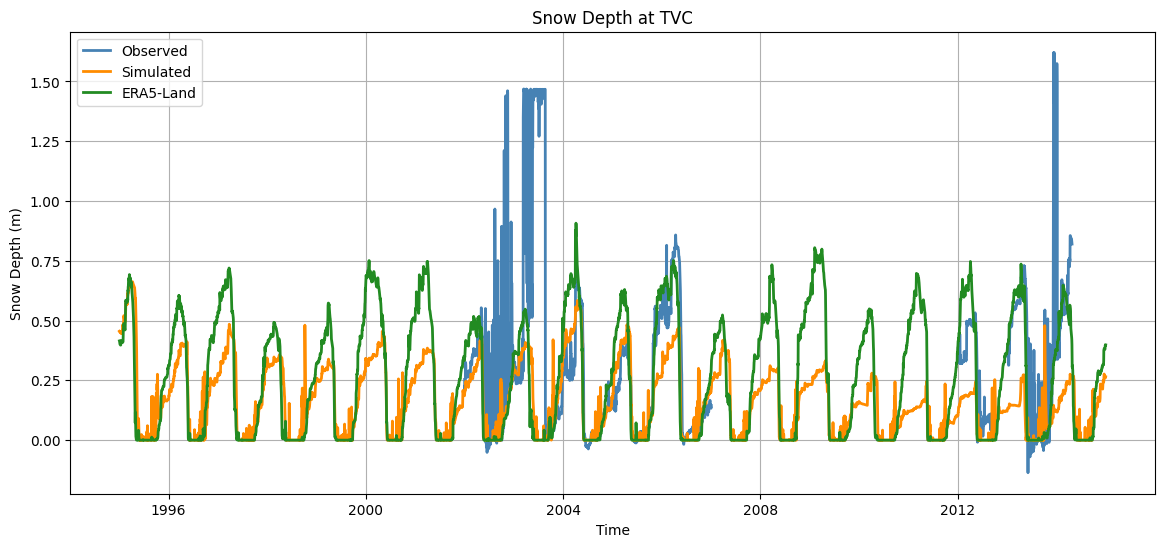

In [116]:
final_plot_sd(ds_obs, ds_ctsm, era['sde'], f"{site}", ds_obs.depth, f"{vari}", 1)